# Dijkstra's Algorithm and Front Propagation

Dijkstra computes geodesic distances on weighted graphs. Beyond final distance maps, we track accepted sets to visualize progressive front propagation.


## Grid graph and incremental accepted front


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

import heapq
OUT = Path("python/dijkstra"); OUT.mkdir(parents=True, exist_ok=True)
n = 120
x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)
w = 1.0 + 2.8*np.exp(-((X-0.1)**2+(Y+0.1)**2)/0.05) + 1.8*np.exp(-((X+0.25)**2+(Y-0.25)**2)/0.03)
src = (8, 8)
dist = np.full((n, n), np.inf)
visited = np.zeros((n, n), dtype=bool)
dist[src] = 0.0
pq = [(0.0, src[0], src[1])]
snaps = {}
marks = [1500, 4500, 9000, 13000]
count = 0
while pq:
    d, i, j = heapq.heappop(pq)
    if visited[i, j]:
        continue
    visited[i, j] = True
    count += 1
    if count in marks:
        snaps[count] = visited.copy()
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ii, jj = i + di, j + dj
        if 0 <= ii < n and 0 <= jj < n and not visited[ii, jj]:
            nd = d + 0.5*(w[i,j] + w[ii,jj])
            if nd < dist[ii, jj]:
                dist[ii, jj] = nd
                heapq.heappush(pq, (nd, ii, jj))



## Accepted nodes through time


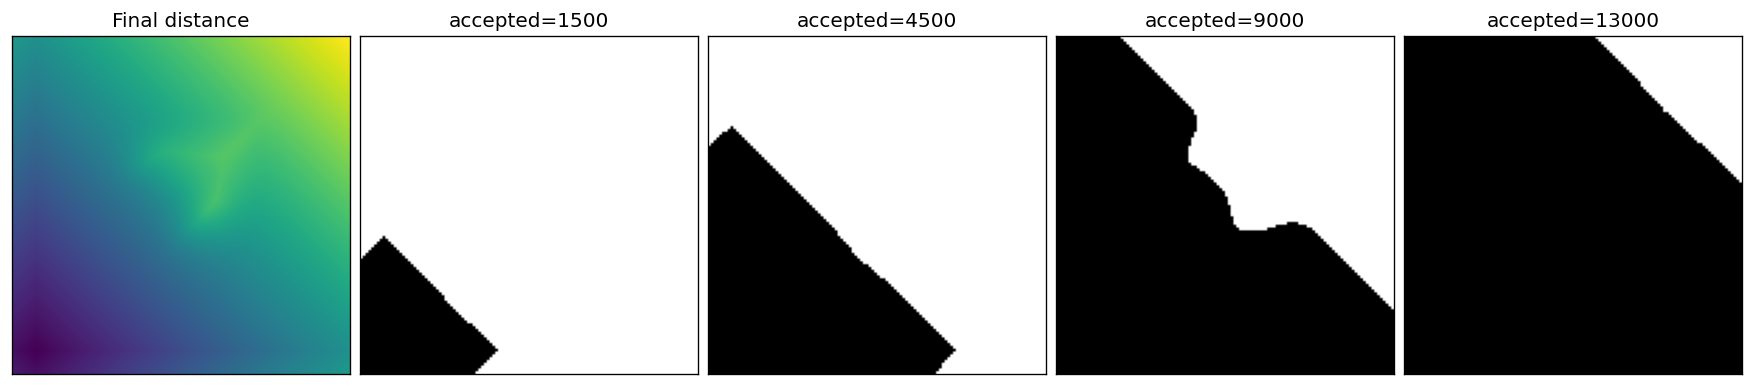

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 3.2), constrained_layout=True)
axes[0].imshow(dist, origin="lower", cmap="viridis")
axes[0].set_title("Final distance")
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, m in zip(axes[1:], [1500, 4500, 9000, 13000]):
    ax.imshow(snaps[m], origin="lower", cmap="gray_r")
    ax.set_title(f"accepted={m}")
    ax.set_xticks([]); ax.set_yticks([])
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()

